# Survey experiment runs

`compare_experiments.ipynb` answers *"which of these two runs is better?"* — a curated head-to-head.
This one answers **"what is in this set of runs, and what does it collectively tell me?"**

**Point it at whatever you have.** All four inputs are accepted and can be mixed:

| input | example | means |
|---|---|---|
| artifacts super-folder | `artifacts/experiments` | every run beneath it |
| campaign config folder | `experiments/strategy_window_2026_08` | the runs those definitions produced |
| a single config file | `experiments/strategy_window_2026_08/classifier_2500.yaml` | that experiment's runs |
| an individual run | `artifacts/experiments/classifier_2500_20260803_005940` | just that run |

Written for a portfolio spanning **three prediction strategies**, which limits what can be compared:

| strategy | predicts | `predicted_edge` units | MAE? | probabilities? |
|---|---|---|---|---|
| `total_points_regressor` | the game total | points vs the line | yes | no |
| `line_error_regressor` | total − line | points vs the line | yes | no |
| `over_under_classifier` | P(OVER) | **EV difference** | no | yes |

So **ROI, win rate and bet volume lead** — they are the only currency common to all three. MAE is
regressor-only (§7) and log-loss/calibration classifier-only (§8); each section skips the runs it
does not apply to rather than plotting misleading blanks.

> Discovery, artifact loading, chart construction and verdict wording live in
> `training_pipeline.reporting`, so this notebook stays about *what to look at*.

In [17]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "pyproject.toml").exists():
    raise RuntimeError("Could not find the project root containing pyproject.toml.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from training_pipeline.reporting import charts, loaders, narrative, rescore, theme
from training_pipeline.reporting.discovery import load_runs

# ===========================================================================
# WHAT TO SURVEY -- any mix of the four input kinds (see the table above).
SOURCES: list[str] = [
    "experiments/strategy_window_2026_08",
]
# Examples:
#   SOURCES = ["experiments/strategy_window_2026_08"]          # one campaign
#   SOURCES = ["experiments/strategy_window_2026_08",
#              "artifacts/experiments_smoke"]                  # campaign + another folder
#   SOURCES = ["artifacts/experiments/classifier_2500_20260803_005940"]   # one run

# Where run directories live. Only used to resolve config folders/files to runs.
ARTIFACTS_ROOT = "artifacts/experiments"

# Optional narrowing. None = keep everything (this is a survey).
ONLY_STRATEGIES: list[str] | None = None      # e.g. ["line_error_regressor"]
ONLY_COMPARISON_GROUP: str | None = None      # e.g. "strategy_window_2026_08"

# --- bet threshold used for THIS analysis ----------------------------------
# Each run froze its own threshold into its artifacts when it ran, so runs made
# before and after a config change report at different thresholds while sitting
# in the same leaderboard columns. Setting these re-scores every run from its
# raw predictions at one common threshold, so the comparison is like-for-like.
# None = leave each run at whatever it was saved with.
#
# Units differ by strategy and one number cannot serve both:
#   RESCORE_EDGE_THRESHOLD -- regressors, points away from the line
#   RESCORE_EV_THRESHOLD   -- classifiers, expected value per unit staked
RESCORE_EDGE_THRESHOLD: float | None = 0.1
RESCORE_EV_THRESHOLD: float | None = 0.0
# ===========================================================================

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)
theme.apply_theme()

runs = theme.prepare_runs(
    load_runs(SOURCES, artifacts_root=ARTIFACTS_ROOT, project_root=PROJECT_ROOT)
)

if ONLY_STRATEGIES:
    runs = runs[runs["prediction_strategy"].isin(ONLY_STRATEGIES)]
if ONLY_COMPARISON_GROUP:
    runs = runs[runs["comparison_group"] == ONLY_COMPARISON_GROUP]
if runs.empty:
    raise ValueError("Every run was filtered out. Relax ONLY_STRATEGIES / ONLY_COMPARISON_GROUP.")

show = lambda messages: [display(Markdown(m)) for m in messages]   # noqa: E731

print(f"{len(runs)} run(s) from {runs['source_path'].nunique()} folder(s):")
for path, count in runs["source_path"].value_counts().items():
    print(f"  {path}  ->  {count} run(s)")

# Re-score every run at the common threshold BEFORE any section reads the frame,
# so the whole notebook speaks about one measurement rather than a mixture.
rescored = pd.DataFrame()
if RESCORE_EDGE_THRESHOLD is not None or RESCORE_EV_THRESHOLD is not None:
    saved_thresholds = sorted(runs["bet_min_edge"].dropna().unique())
    rescored = rescore.rescore_runs(
        runs,
        edge_threshold=RESCORE_EDGE_THRESHOLD,
        ev_threshold=RESCORE_EV_THRESHOLD,
    )
    covered = set(rescored["label"])
    runs = rescore.apply_rescored(runs, rescored)
    print("")
    print(f"Re-scored {len(covered)}/{len(runs)} run(s) at "
          f"edge>{RESCORE_EDGE_THRESHOLD} (regressors), "
          f"EV>{RESCORE_EV_THRESHOLD} (classifiers).")
    print(f"  thresholds as saved were: {saved_thresholds}")
    if missing := set(runs["label"]) - covered:
        # Named, never silent: a dropped run looks exactly like a run that was
        # never there, and would keep reporting its own frozen threshold.
        print(f"  NOT re-scored (no usable predictions): {sorted(missing)}")

6 run(s) from 1 folder(s):
  /home/adrian_alvarez/Projects/NBA_over_under_predictor/artifacts/experiments  ->  6 run(s)

Re-scored 6/6 run(s) at edge>0.1 (regressors), EV>0.0 (classifiers).
  thresholds as saved were: [np.float64(0.0), np.float64(2.0)]


## 0. At a glance — did the cross-validated edge survive the test?

The two headline questions, before any of the detail below.

**First: cross-validation → held-out test.** Both win rates are measured at each run's own bet
threshold, so this is like-for-like. Expect a drop — the CV folds chose the hyperparameters, so they
flatter the model. What matters is whether anything is left afterwards, and whether the run clears
break-even (**52.38%**) in *both*. Clearing it in one and not the other is the signature of noise.

> **`cv_win_rate` is not the number Optuna optimised, and can sit below 50% even for a run whose
> search reported a much higher figure.** Two things separate them, and both are deliberate:
>
> 1. **Threshold.** Optuna's `mean_ou_acc` scores *every* validation game. `cv_win_rate` scores only
>    the games that clear the bet threshold. Since a bigger predicted edge does not reliably win more
>    often (see the next panel), that filter can easily *lower* the win rate while cutting volume.
> 2. **Early stopping.** During tuning each fold is fitted with `eval_set` on the fold itself, so the
>    number of boosting rounds is chosen by looking at the very data the fold is then scored on, and
>    predictions use that fold-specific best iteration. `cv_win_rate` refits with a single fixed round
>    count and no `eval_set`, so nothing is chosen using the scored data.
>
> The second effect is worth a number: on these runs the fold accuracies Optuna recorded sit about
> **7 points above** the same folds re-scored without the peek, in 11 of 12 folds. So Optuna's
> reported CV accuracy is an optimistic upper bound, and `cv_win_rate` is the conservative,
> comparable-to-the-holdout measurement. Judge runs on the latter.

**Second: does a bigger predicted edge win more often?** This is the assumption every minimum-edge
threshold rests on: that a game the model puts 3 points away from the line is a better bet than one it
puts 0.5 points away. Predictions are grouped by `|predicted total − line|` in points, and each range
reports its bet count and win rate.

Two deliberate choices in that second analysis:

- **Every candidate game is included, not just those above the current threshold.** Filtering first
  would bake the filter's own effect into the answer, and the ranges below the threshold are exactly
  the ones you need to see to judge whether discarding them was right.
- **Regressors only.** Their `predicted_edge` is points away from the line; a classifier's is a
  difference of expected values. Pooling them would be adding unlike quantities.

Ranges are pooled across runs, because one run's 0.5–1.0 bucket holds a few dozen games — nowhere near
enough to tell 55% from 50%. Bins under 30 bets are flagged and should not be read.

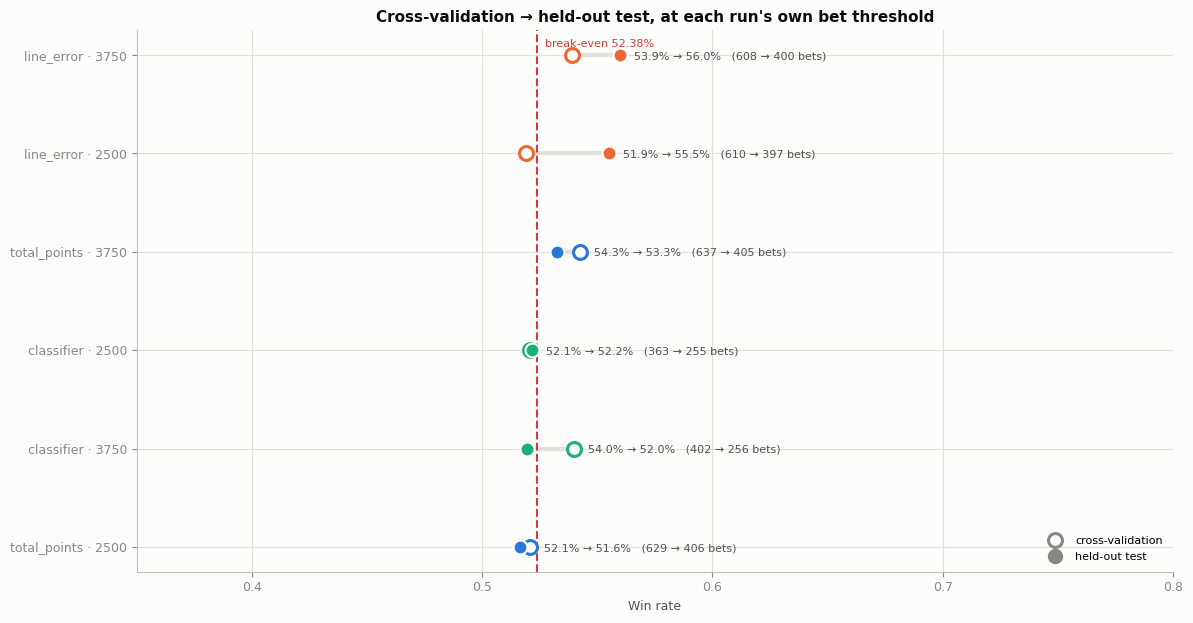

,label,prediction_strategy,holdout_evaluation,cv_win_rate,cv_n_bets,win_rate,n_bets,win_rate_drop,cv_roi,roi
0,line_error · 3750,line_error_regressor,daily_walk_forward,53.88%,608,55.98%,400,-2.10%,2.86%,6.75%
1,line_error · 2500,line_error_regressor,daily_walk_forward,51.89%,610,55.50%,397,-3.60%,-0.92%,5.86%
2,total_points · 3750,total_points_regressor,daily_walk_forward,54.26%,637,53.27%,405,0.99%,3.57%,1.66%
3,classifier · 2500,over_under_classifier,daily_walk_forward,52.07%,363,52.16%,255,-0.09%,-0.60%,-0.43%
4,classifier · 3750,over_under_classifier,daily_walk_forward,53.98%,402,51.95%,256,2.03%,3.05%,-0.82%
5,total_points · 2500,total_points_regressor,daily_walk_forward,52.08%,629,51.63%,406,0.45%,-0.58%,-1.41%


Across 6 run(s) the median move from cross-validation to the held-out test is **-0.18%** in win rate. A drop is the expected direction: the folds chose the hyperparameters, so they flatter the model. What matters is whether anything is left after it.

Runs above break-even in **both**: `line_error · 3750` (CV 53.9% → test 56.0%), `total_points · 3750` (CV 54.3% → test 53.3%). These are the only ones worth carrying forward — and still only on 400–405 test bets.

_Above break-even on the test but not in cross-validation: `line_error · 2500`. With the larger CV sample disagreeing, treat the test figure as the fluke._

[None, None, None]

In [18]:
# Edge ranges in points. Fine at the bottom, where "is 1 point better than 0.5?"
# actually lives; coarser in the tail, where large edges are rare.
EDGE_BINS = charts.DEFAULT_EDGE_BINS   # (0, 0.5, 1, 1.5, 2, 3, 4, 6, inf)

comparison = charts.plot_cv_vs_test_win_rate(runs)
if comparison.empty:
    display(Markdown("_No run reports both a cross-validation and a holdout win rate._"))
else:
    display(theme.percent_frame(
        comparison,
        percent=["cv_win_rate", "win_rate", "win_rate_drop", "cv_roi", "roi"],
    ))
show(narrative.cv_vs_test_win_rate(comparison))

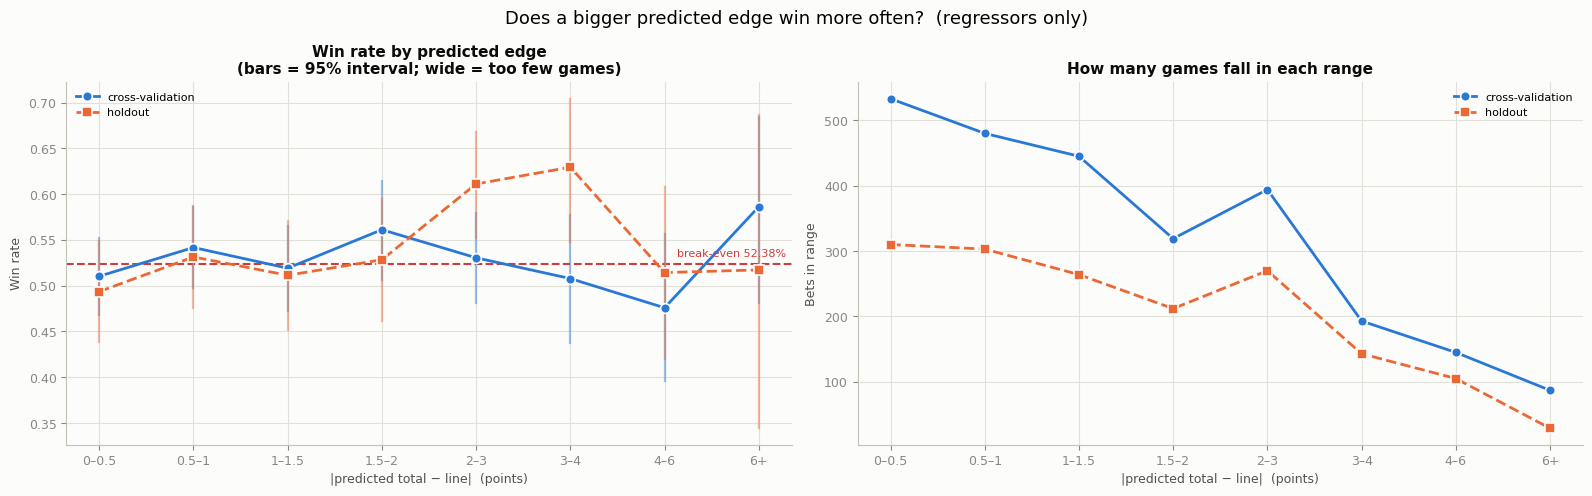

**Pooled across regression runs** — bets and win rate per edge range

,source,edge_range,runs,n_bets,n_wins,pct_of_games,win_rate,ci_low,ci_high,too_few_to_read
0,cross-validation,0–0.5,4,533,272,20.53%,51.03%,46.80%,55.25%,False
1,cross-validation,0.5–1,4,480,260,18.49%,54.17%,49.69%,58.57%,False
2,cross-validation,1–1.5,4,445,231,17.14%,51.91%,47.27%,56.52%,False
3,cross-validation,1.5–2,4,319,179,12.29%,56.11%,50.63%,61.45%,False
4,cross-validation,2–3,4,394,209,15.18%,53.05%,48.11%,57.92%,False
5,cross-validation,3–4,4,193,98,7.43%,50.78%,43.78%,57.75%,False
6,cross-validation,4–6,4,145,69,5.59%,47.59%,39.62%,55.67%,False
7,cross-validation,6+,4,87,51,3.35%,58.62%,48.12%,68.39%,False
8,holdout,0–0.5,4,310,153,18.95%,49.35%,43.83%,54.89%,False
9,holdout,0.5–1,4,303,161,18.52%,53.14%,47.51%,58.68%,False


- **cross-validation**: win rate goes from **51.0%** in the 0–0.5 point range (533 bets) to **58.6%** in 6+ (87 bets). Rank correlation across ranges **+0.02**. **No usable trend**: a bigger predicted edge does not win more often here.

- **holdout**: win rate goes from **49.4%** in the 0–0.5 point range (310 bets) to **51.4%** in 4–6 (105 bets). Rank correlation across ranges **+0.50**. A weak, non-monotone trend — not something to size bets on.

_1 range/source cell(s) hold fewer than 30 bets and are shown but not readable (6+). Large edges are rare, so their win rates swing wildly on a handful of games — the widest intervals in the chart._

**What this means for the bet threshold.** If win rate is flat across ranges, raising the minimum edge does not improve bet quality — it only discards volume, and volume is what every significance test here is short of. The best readable range is `3–4` at 62.9% on 143 bets (holdout); check whether that is meaningfully above the ranges you are currently discarding before keeping the filter.

**If the bet threshold were set here** — cumulative, i.e. every game at or above that edge. This is the table to read when choosing a threshold: a higher win rate is only worth it if the volume it leaves still supports a conclusion.

,source,threshold_at_range_floor,n_at_or_above,pct_at_or_above,win_rate_at_or_above
0,cross-validation,0–0.5,2596,100.00%,52.73%
1,cross-validation,0.5–1,2063,79.47%,53.17%
2,cross-validation,1–1.5,1583,60.98%,52.87%
3,cross-validation,1.5–2,1138,43.84%,53.25%
4,cross-validation,2–3,819,31.55%,52.14%
5,cross-validation,3–4,425,16.37%,51.29%
6,cross-validation,4–6,232,8.94%,51.72%
7,cross-validation,6+,87,3.35%,58.62%
8,holdout,0–0.5,1636,100.00%,54.10%
9,holdout,0.5–1,1326,81.05%,55.20%


**Per run, cumulative** — every column is *all games at or above that edge*, which is what a threshold set there would bet. Three rows per run: cross-validation win rate, holdout win rate, and the share of that run's games qualifying. Read a win rate against the `% of games` row directly below it — the far-right columns are always the thinnest.

In [19]:
breakdown = charts.edge_range_breakdown(runs, bins=EDGE_BINS, regressors_only=True)
pooled = charts.pool_edge_ranges(breakdown)

if pooled.empty:
    display(Markdown(
        "_No regression runs with usable predictions, so there is no edge breakdown to show._"
    ))
else:
    charts.plot_edge_ranges(pooled)

    range_order = pooled.sort_values("edge_low")["edge_range"].drop_duplicates().tolist()

    display(Markdown("**Pooled across regression runs** — bets and win rate per edge range"))
    display(theme.percent_frame(
        pooled[["source", "edge_range", "runs", "n_bets", "n_wins", "pct_of_games",
                "win_rate", "ci_low", "ci_high", "too_few_to_read"]],
        percent=["pct_of_games", "win_rate", "ci_low", "ci_high"],
    ))
    show(narrative.edge_ranges(pooled))

    # --- what a threshold set at each range's floor would actually buy -------
    # Cumulative, so it answers the operational question directly: keep this
    # much volume, at this win rate.
    display(Markdown(
        "**If the bet threshold were set here** — cumulative, i.e. every game at or above "
        "that edge. This is the table to read when choosing a threshold: a higher win rate "
        "is only worth it if the volume it leaves still supports a conclusion."
    ))
    display(theme.percent_frame(
        pooled[["source", "edge_range", "n_at_or_above", "pct_at_or_above",
                "win_rate_at_or_above"]]
        .rename(columns={"edge_range": "threshold_at_range_floor"}),
        percent=["pct_at_or_above", "win_rate_at_or_above"],
    ))

    # --- per run: a pooled trend can hide one run behaving differently -------
    # Cumulative, so each column is every game at or above that edge -- the
    # population a threshold there would actually bet, rather than a narrow
    # band that can hold a handful of games and swing wildly.
    combined = charts.combined_edge_table(breakdown, cumulative=True)
    combined_order = combined["column"].cat.categories.tolist()
    display(Markdown(
        "**Per run, cumulative** — every column is *all games at or above that edge*, which "
        "is what a threshold set there would bet. Three rows per run: cross-validation win "
        "rate, holdout win rate, and the share of that run's games qualifying. Read a win "
        "rate against the `% of games` row directly below it — the far-right columns are "
        "always the thinnest."
    ))
    display(
        combined.pivot_table(index=["label", "source"], columns="column",
                             values="value", observed=True)
        .reindex(columns=combined_order)
        .style.format("{:.1%}", na_rep="—")
    )

## 1. What is in this set

Coverage first. A conclusion like "classifiers lose" drawn from one classifier run and six regressor
runs is a statement about the sample, not about classifiers.

,label,prediction_strategy,train_games,comparison_group,training_version,data_version,holdout_n_games,n_bets,n_seeds,created_at,source_root
0,line_error · 2500,line_error_regressor,2500,strategy_window_2026_08,2.0,20260704-2_0-with-overtime-col,416,397,3,2026-08-02 23:38:59.749445+00:00,experiments
1,line_error · 3750,line_error_regressor,3750,strategy_window_2026_08,2.0,20260704-2_0-with-overtime-col,416,400,3,2026-08-03 01:47:35.482361+00:00,experiments
2,classifier · 2500,over_under_classifier,2500,strategy_window_2026_08,2.0,20260704-2_0-with-overtime-col,409,255,3,2026-08-03 00:59:40.513408+00:00,experiments
3,classifier · 3750,over_under_classifier,3750,strategy_window_2026_08,2.0,20260704-2_0-with-overtime-col,409,256,3,2026-08-03 03:34:20.332202+00:00,experiments
4,total_points · 2500,total_points_regressor,2500,strategy_window_2026_08,2.0,20260704-2_0-with-overtime-col,416,406,3,2026-08-03 00:23:17.440357+00:00,experiments
5,total_points · 3750,total_points_regressor,3750,strategy_window_2026_08,2.0,20260704-2_0-with-overtime-col,416,405,3,2026-08-03 02:54:46.715436+00:00,experiments


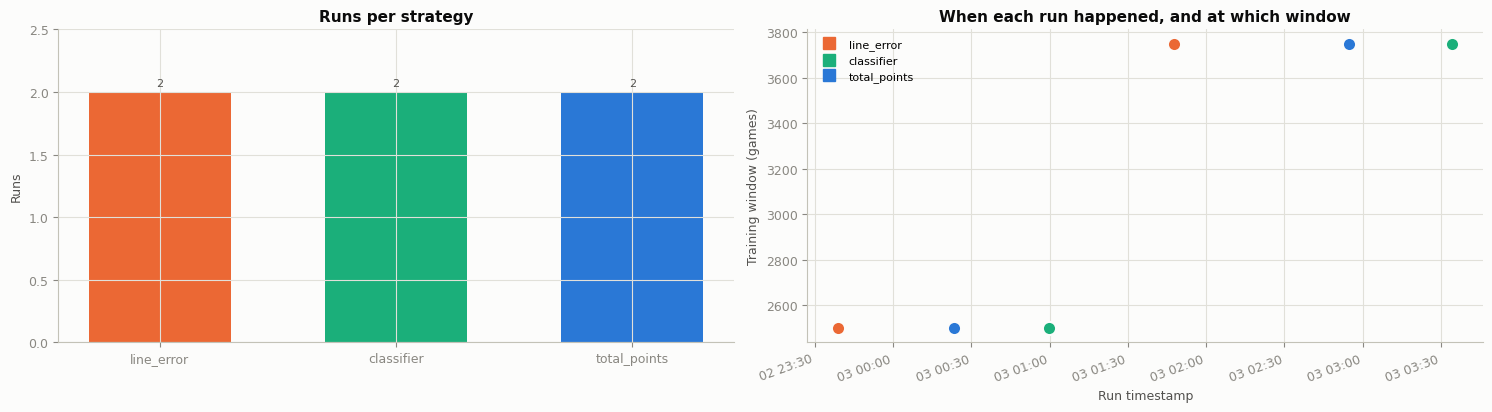

[]

In [20]:
overview = ["label", "prediction_strategy", "train_games", "comparison_group",
            "training_version", "data_version", "holdout_n_games", "n_bets",
            "n_seeds", "created_at", "source_root"]
display(runs[[c for c in overview if c in runs.columns]])

per_strategy = charts.plot_portfolio(runs)
show(narrative.coverage(per_strategy))

## 2. What is actually comparable

Two traps specific to a mixed-strategy set, both easy to miss because every run reports a column
called `bet_min_edge`:

1. **The threshold means different things.** Regressors bet when `|predicted_edge| > t`, in **points**.
   The classifier bets when its **expected value** exceeds `t`. Same column, different units — so
   `bet_rate` is the honest way to compare how choosy two runs are.
2. **Different holdout cohorts.** ROI is only comparable between runs scored on the same games.

,label,holdout_start,holdout_end,holdout_n_games,n_candidates,bet_min_edge,bet_rate,data_version
0,line_error · 2500,2026-02-19T00:00:00,2026-04-17T00:00:00,416,416,0.1,0.954327,20260704-2_0-with-overtime-col
1,line_error · 3750,2026-02-19T00:00:00,2026-04-17T00:00:00,416,416,0.1,0.961538,20260704-2_0-with-overtime-col
2,classifier · 2500,2026-02-19T00:00:00,2026-04-17T00:00:00,409,409,0.0,0.623472,20260704-2_0-with-overtime-col
3,classifier · 3750,2026-02-19T00:00:00,2026-04-17T00:00:00,409,409,0.0,0.625917,20260704-2_0-with-overtime-col
4,total_points · 2500,2026-02-19T00:00:00,2026-04-17T00:00:00,416,416,0.1,0.975962,20260704-2_0-with-overtime-col
5,total_points · 3750,2026-02-19T00:00:00,2026-04-17T00:00:00,416,416,0.1,0.973558,20260704-2_0-with-overtime-col


⚠️ **2 different holdout cohorts present.** Runs are only directly comparable within a cohort; across cohorts the baselines differ too.

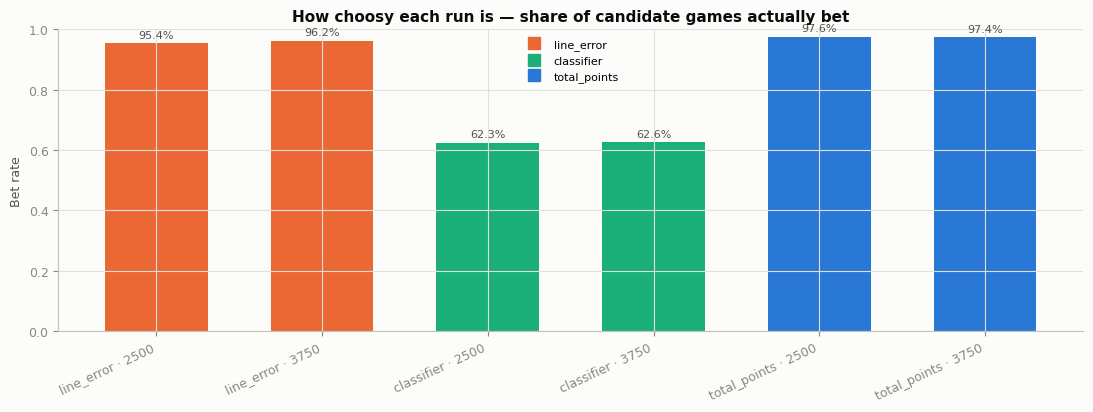

**Threshold units by strategy** — the same number is not the same filter:

- `line_error`: threshold [0.1] (points vs the line)
- `classifier`: threshold [0.0] (expected value)
- `total_points`: threshold [0.1] (points vs the line)

[None]

In [21]:
cohort_columns = ["label", "holdout_start", "holdout_end", "holdout_n_games",
                  "n_candidates", "bet_min_edge", "bet_rate", "data_version"]
display(runs[[c for c in cohort_columns if c in runs.columns]])
show(narrative.cohorts(runs))

charts.plot_selectivity(runs)
show(narrative.threshold_units(runs))

## 3. Headline — ROI against the noise floor

Each bar is a run's holdout ROI. The vertical rule through it is the range that **same configuration**
produced across random seeds, with nothing else changed — only XGBoost's own row/column subsampling.

**Read the rule first.** A difference between two runs smaller than one run's own seed range is not
evidence of anything. Runs without a rule have no seed data and are unqualified point estimates.

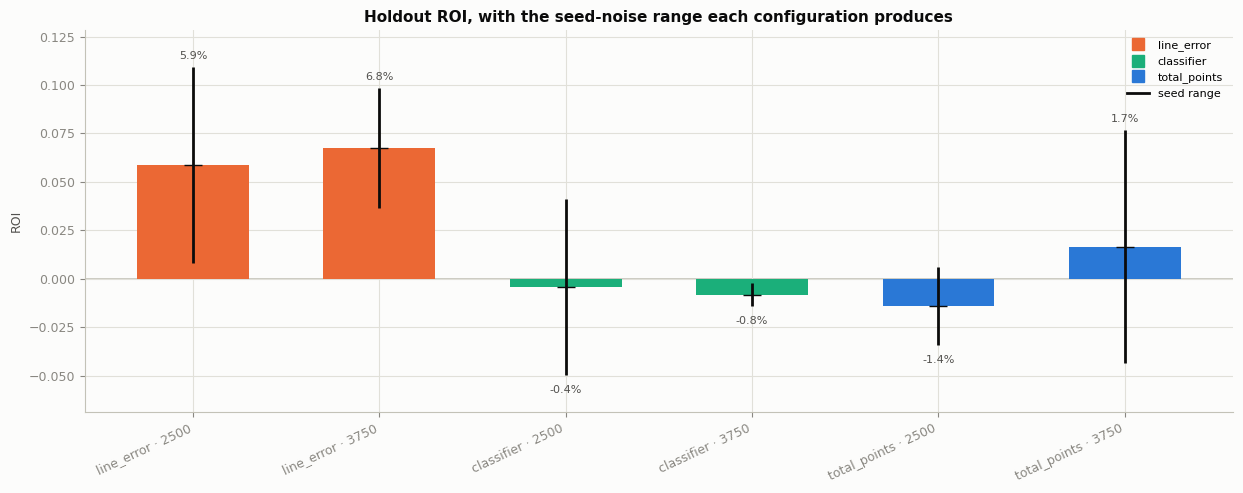

⚠️ Best-to-worst ROI spread is **8.16%** (line_error · 3750 +6.75% vs total_points · 2500 -1.41%), which is **smaller** than the widest seed range (**11.98%**) — this selection cannot distinguish its runs from one another.

[None]

In [22]:
charts.plot_roi_with_seed_noise(runs)
show(narrative.seed_noise(runs))

## 4. Volume — can any of this be proven?

At −110 break-even is **52.38%**. Whether a win rate clears it *reliably* depends almost entirely on
how many bets stand behind it. A 95% Wilson interval crossing the break-even line means "not proven",
however good the point estimate looks.

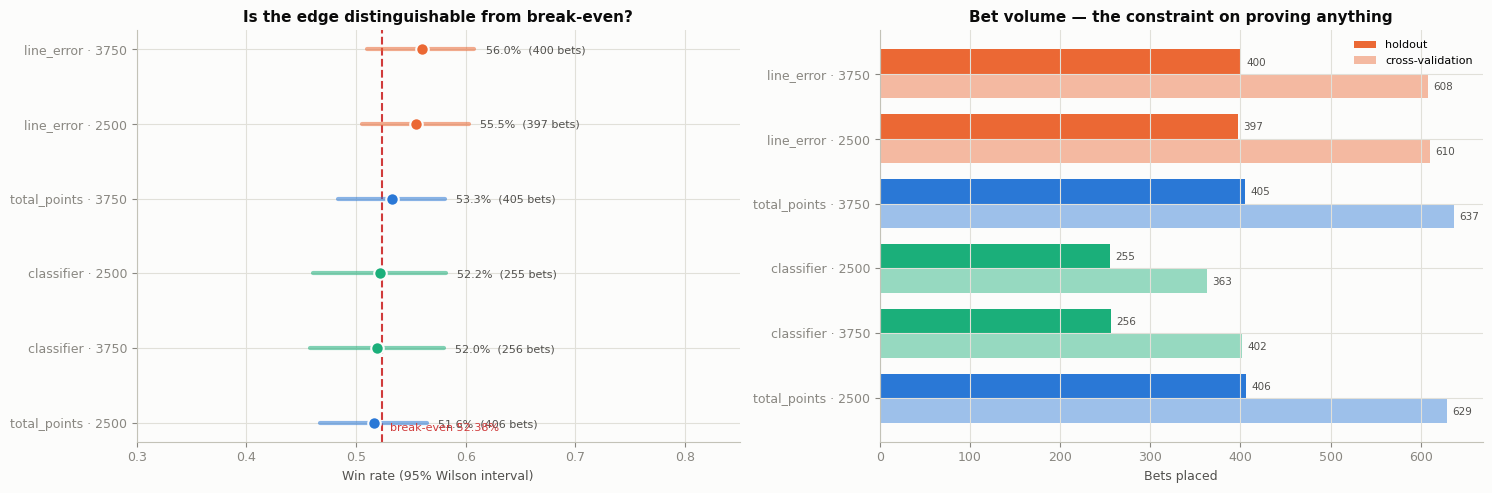

**No run here has a win-rate interval clearing break-even.** At these volumes that is the expected outcome rather than a surprise: even a genuine 55% win rate needs on the order of a thousand bets before its interval separates from 52.38%. Treat every ROI as a hypothesis.

[None]

In [23]:
charts.plot_significance_and_volume(runs)
show(narrative.significance(runs))

## 5. Cross-validation versus holdout

The CV folds chose the hyperparameters, so their profit is optimistically biased. The holdout did not,
so it is honest but thin. Reading them together beats either alone:

- **Agree, both positive** — the strongest signal available.
- **CV ≫ holdout** — selection overfitting: the search fitted the folds.
- **Holdout ≫ CV** — usually the small holdout being lucky, not a model that improves out of sample.
  Treat a large positive gap with the same suspicion as a large negative one.

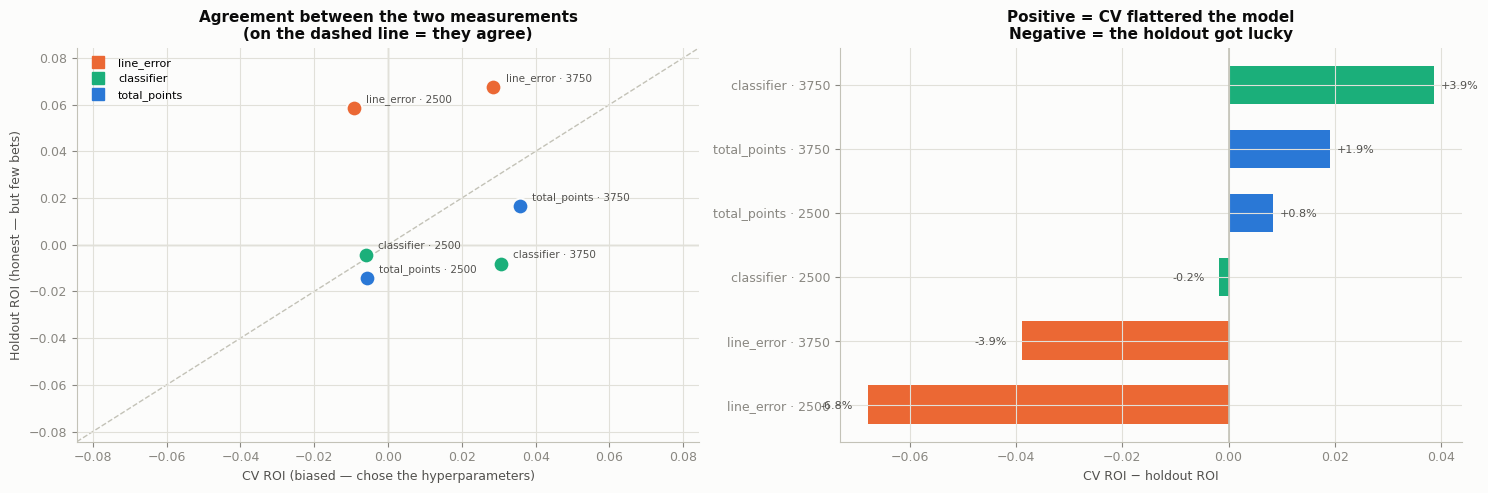

,label,cv_roi,holdout_roi,gap,same_sign,cv_bets,holdout_bets,cv_profitable_folds
0,line_error · 2500,-0.92%,5.86%,-6.79%,False,610,397,6
1,line_error · 3750,2.86%,6.75%,-3.89%,True,608,400,11
2,classifier · 2500,-0.60%,-0.43%,-0.17%,True,363,255,6
3,classifier · 3750,3.05%,-0.82%,3.87%,False,402,256,8
4,total_points · 2500,-0.58%,-1.41%,0.83%,True,629,406,3
5,total_points · 3750,3.57%,1.66%,1.91%,True,637,405,7


**4 of 6 run(s) agree on the sign** of their edge between CV and holdout. Runs agreeing on sign are the ones worth carrying forward.

[None]

In [24]:
agreement = charts.plot_cv_vs_holdout(runs)
if not agreement.empty:
    display(theme.percent_frame(agreement, percent=["cv_roi", "holdout_roi", "gap"]))
show(narrative.cv_agreement(agreement))

## 6. Strategy and window

The comparison this set probably exists to make, using the measures every strategy reports. Bear in
mind the three bet at very different rates, so equal ROI on very different volumes is not equal.

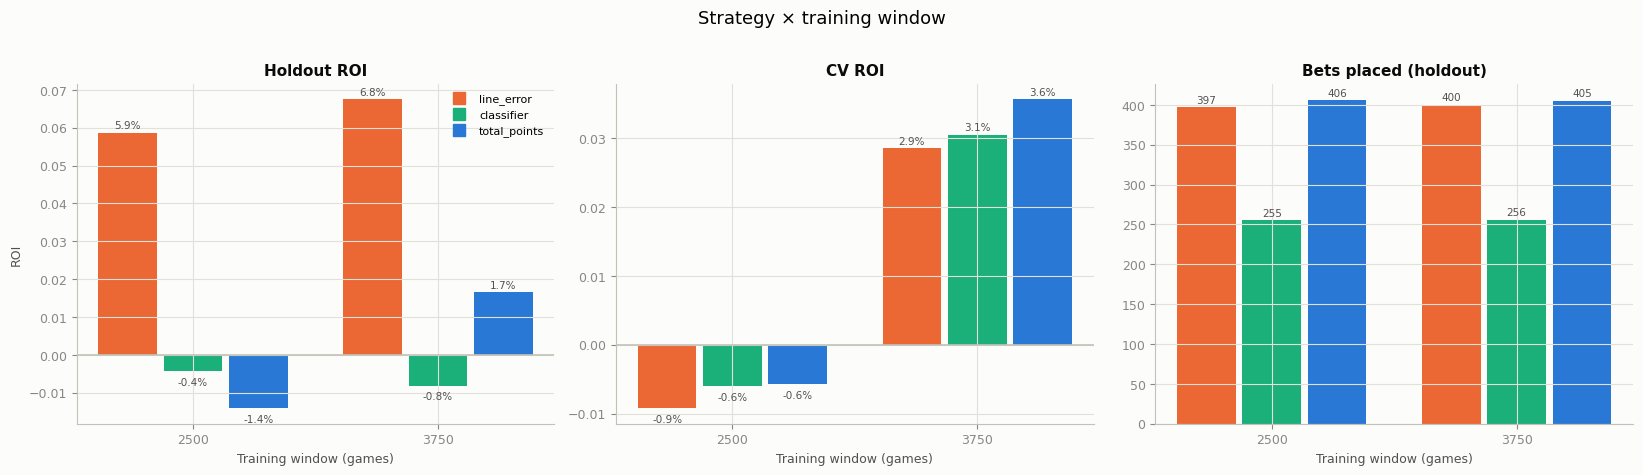

,strategy_short,runs,mean_roi,best_roi,worst_roi,mean_cv_roi,mean_bets,mean_bet_rate,mean_win_rate
0,classifier,2,-0.62%,-0.43%,-0.82%,1.23%,255.500000,62.47%,52.05%
1,line_error,2,6.31%,6.75%,5.86%,0.97%,398.500000,95.79%,55.74%
2,total_points,2,0.13%,1.66%,-1.41%,1.49%,405.500000,97.48%,52.45%


Mean-ROI spread between strategies is **6.93%**, against a worst-case seed range of **11.98%**. **That is within seed noise** — this selection does not establish that any strategy beats another.

[None]

In [25]:
summary = charts.plot_strategy_window(runs)
display(theme.percent_frame(
    summary,
    percent=["mean_roi", "best_roi", "worst_roi", "mean_cv_roi", "mean_bet_rate", "mean_win_rate"],
))
show(narrative.strategy_spread(summary, runs))

## 7. Regressors only — accuracy against the line

MAE exists only for the regression strategies; the classifier never predicts a total, so it is absent
here by design. What matters is not MAE but **MAE relative to the bookmaker's line on the same games**
— the line is a strong forecaster, so absolute error alone means little.

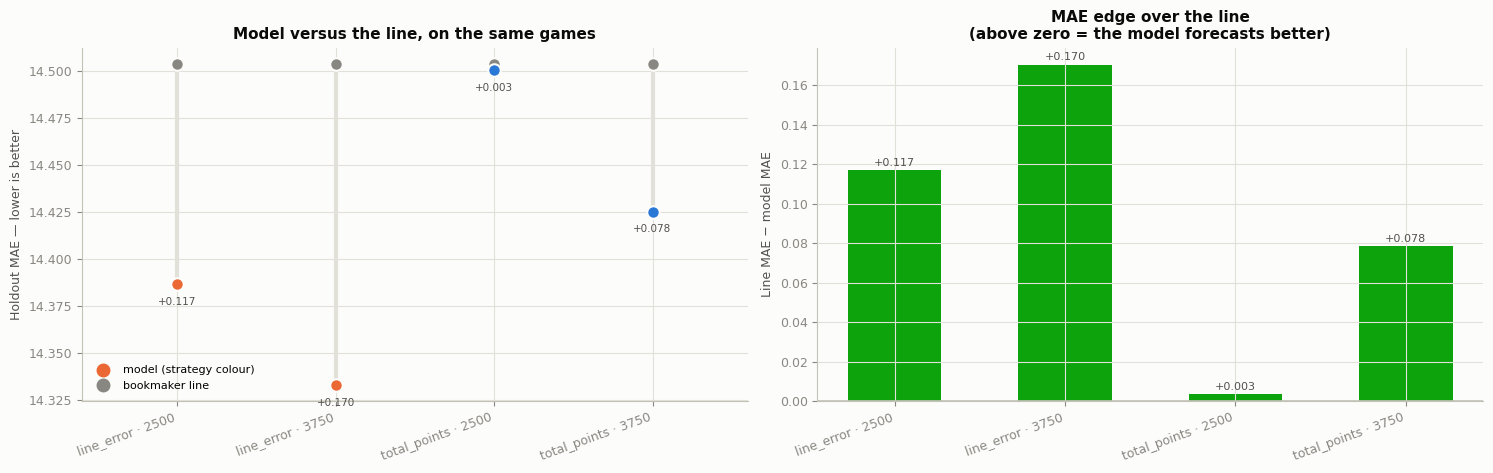

,label,cv_mae,baseline_cv_mae,cv_edge,final_test_mae,baseline_holdout_mae,holdout_edge
0,line_error · 2500,14.717,14.914,0.196,14.387,14.504,0.117
1,line_error · 3750,14.697,14.914,0.217,14.333,14.504,0.170
4,total_points · 2500,14.713,14.914,0.201,14.500,14.504,0.003
5,total_points · 3750,14.645,14.914,0.269,14.425,14.504,0.078


MAE edge and ROI answer different questions: a model can forecast the total slightly better and still lose money if its errors fall on the wrong side of the line, and vice versa. Where they disagree, ROI is the one tied to the decision you actually make.

_Excluded (no MAE by construction): `classifier · 2500`, `classifier · 3750`._

In [26]:
view = charts.plot_regressor_accuracy(runs)
if view is None:
    display(Markdown("_No regression runs in this set._"))
else:
    display(theme.percent_frame(
        view[["label", "cv_mae", "baseline_cv_mae", "cv_edge",
              "final_test_mae", "baseline_holdout_mae", "holdout_edge"]],
        decimals=["cv_mae", "baseline_cv_mae", "cv_edge", "final_test_mae",
                  "baseline_holdout_mae", "holdout_edge"],
    ))
    display(Markdown(
        "MAE edge and ROI answer different questions: a model can forecast the total slightly better "
        "and still lose money if its errors fall on the wrong side of the line, and vice versa. Where "
        "they disagree, ROI is the one tied to the decision you actually make."
    ))

skipped = runs[runs["is_classifier"]]
if not skipped.empty:
    display(Markdown("_Excluded (no MAE by construction): "
                     + ", ".join(f"`{n}`" for n in skipped["label"]) + "._"))

## 8. Classifiers only — are the probabilities honest?

A classifier states a probability, which makes it checkable in a way a point forecast is not:

- **Discrimination** — does it rank games correctly? (`log_loss` vs always predicting the base rate)
- **Calibration** — when it says 60%, do those games go OVER about 60% of the time?

A model can discriminate well and still be badly calibrated, in which case its expected-value bet
filter is systematically wrong even when the ranking is useful. Points on the diagonal of the
reliability curve mean the stated probability can be taken at face value.

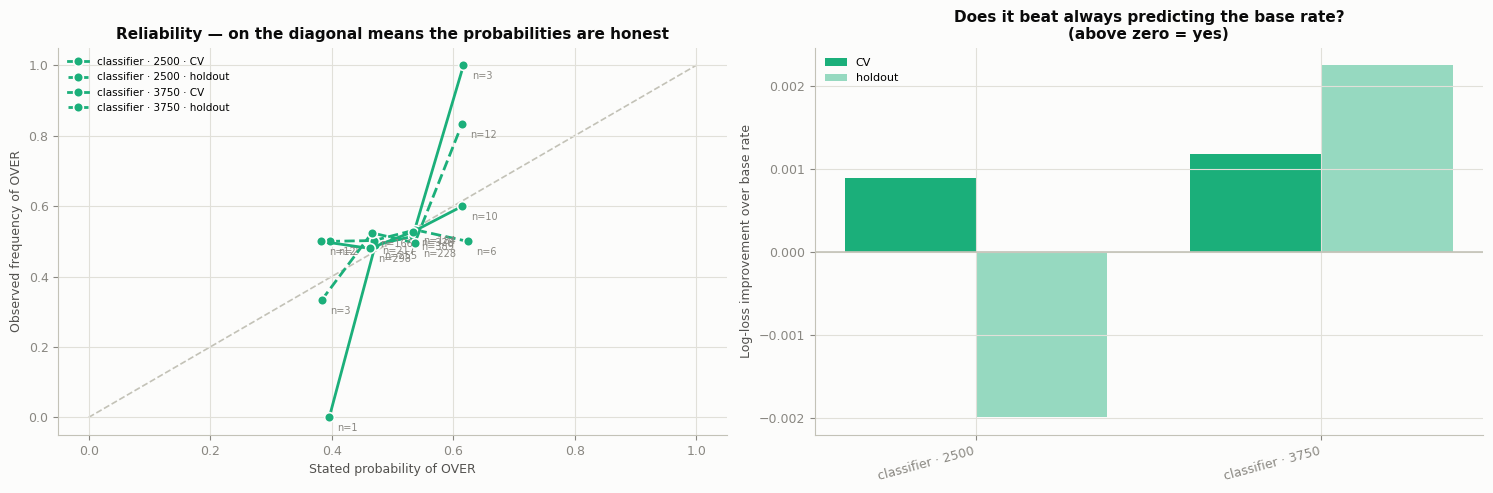

,label,log_loss,cv_log_loss,log_loss_improvement,cv_log_loss_improvement,brier,expected_calibration_error,roi,n_bets,win_rate
2,classifier · 2500,0.695,0.692,-0.002,0.001,0.251,0.022,-0.43%,255,52.16%
3,classifier · 3750,0.690,0.692,0.002,0.001,0.249,0.053,-0.82%,256,51.95%


- **classifier · 2500**: CV log-loss improvement **+0.0009**. Positive, so the probabilities carry information beyond the base rate — though how much is best judged next to the bet volume.

- **classifier · 3750**: CV log-loss improvement **+0.0012**. Positive, so the probabilities carry information beyond the base rate — though how much is best judged next to the bet volume.

In [27]:
classifiers = charts.plot_classifier_calibration(runs)
if classifiers is None:
    display(Markdown("_No classifier runs in this set._"))
else:
    metrics = ["label", "log_loss", "cv_log_loss", "log_loss_improvement",
               "cv_log_loss_improvement", "brier", "expected_calibration_error",
               "roi", "n_bets", "win_rate"]
    display(theme.percent_frame(
        classifiers[[c for c in metrics if c in classifiers.columns]],
        percent=["roi", "win_rate"],
        decimals=["log_loss", "cv_log_loss", "log_loss_improvement",
                  "cv_log_loss_improvement", "brier", "expected_calibration_error"],
    ))
    show(narrative.classifier_quality(classifiers))

## 9. Does the model's own confidence predict winning?

The premise behind every minimum-edge filter: a bet the model feels strongly about should win more
often than a marginal one. If that is false, raising the threshold does not improve bet quality — it
only discards volume, which is the one thing in short supply.

Confidence is not in the same units across strategies, so the shared axis is each run's **own
confidence percentile**. "Top 20% most confident" is meaningful for every strategy.

**Read the trend table, not the shape.** With five buckets a line can look convincingly monotone and
still be noise, so the decision rests on a single Spearman test over the ungrouped data rather than
five per-bucket comparisons that would yield about one spurious "significant" bucket at 95%.
Where the chart and the table disagree, the table wins.

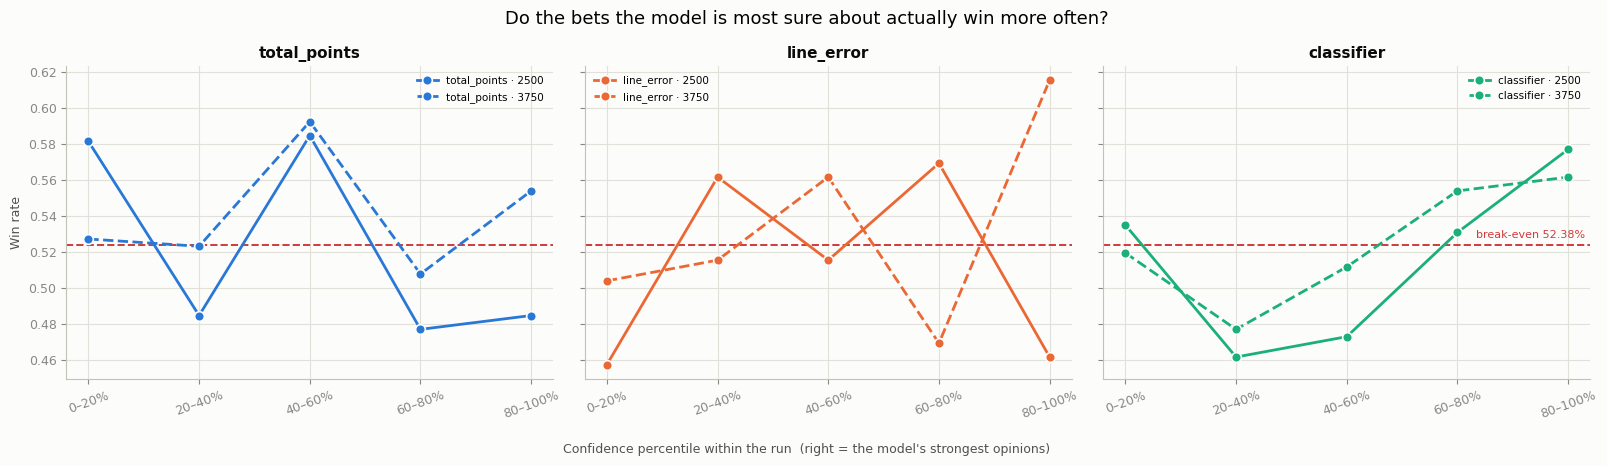

bucket,0–20%,20–40%,40–60%,60–80%,80–100%
label,,,,,
classifier · 2500,53.5%,46.2%,47.3%,53.1%,57.7%
classifier · 3750,51.9%,47.7%,51.2%,55.4%,56.2%
line_error · 2500,45.7%,56.2%,51.5%,56.9%,46.2%
line_error · 3750,50.4%,51.5%,56.2%,46.9%,61.5%
total_points · 2500,58.1%,48.5%,58.5%,47.7%,48.5%
total_points · 3750,52.7%,52.3%,59.2%,50.8%,55.4%


**Trend test** — Spearman correlation between confidence and winning:

,label,source,n,rho,p_value
1,line_error · 3750,CV,649,+0.0574,0.144
3,classifier · 3750,CV,648,+0.0389,0.323
2,classifier · 2500,CV,648,+0.0341,0.387
0,line_error · 2500,CV,649,+0.0125,0.751
5,total_points · 3750,CV,649,+0.0045,0.908
4,total_points · 2500,CV,649,-0.0504,0.200


⚠️ **No run shows a significant positive relationship between confidence and winning.** On this evidence a higher minimum-edge threshold is not selecting better bets — it is only reducing volume, which makes every other number here harder to prove. Worth testing a lower threshold explicitly before assuming the filter earns its place.

In [28]:
buckets, trend = charts.plot_confidence_calibration(runs)
if buckets.empty:
    display(Markdown("_No prediction files with a `selection_score` column were found._"))
else:
    order = buckets.attrs["bucket_order"]
    display(buckets.pivot_table(index="label", columns="bucket", values="win_rate")
            .reindex(columns=order).style.format("{:.1%}", na_rep="—"))
    display(Markdown("**Trend test** — Spearman correlation between confidence and winning:"))
    display(trend[["label", "source", "n", "rho", "p_value"]]
            .sort_values("rho", ascending=False)
            .style.format({"rho": "{:+.4f}", "p_value": "{:.3f}", "n": "{:.0f}"}, na_rep="—"))
    show(narrative.confidence_trend(trend))

## 10. Fold-by-fold consistency

A pooled ROI is an average, and an average carried by one or two folds is a different proposition from
one that held across twelve.

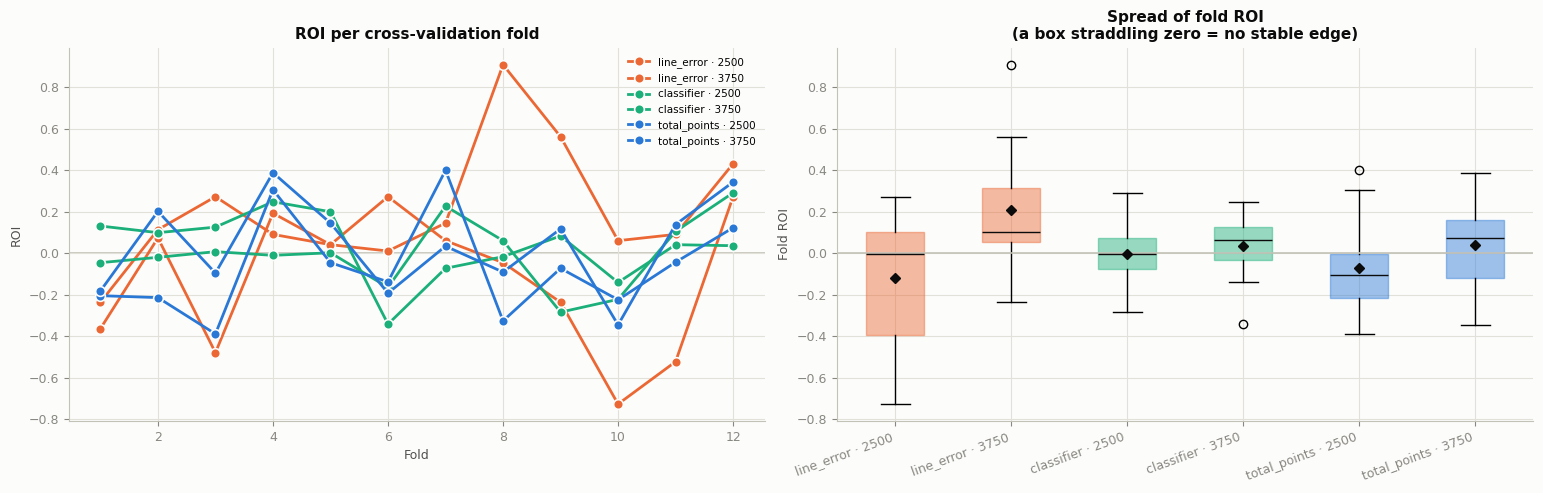

,label,folds,profitable,mean_roi,sd_roi,worst,best,mean_over_sd
0,classifier · 2500,12,6,-0.43%,16.81%,-28.41%,29.14%,-0.026
1,classifier · 3750,12,8,3.28%,16.06%,-34.17%,24.83%,0.204
2,line_error · 2500,12,6,-12.17%,33.59%,-72.73%,27.27%,-0.362
3,line_error · 3750,12,11,20.77%,30.11%,-23.64%,90.91%,0.690
4,total_points · 2500,12,3,-6.90%,24.04%,-38.91%,40.00%,-0.287
5,total_points · 3750,12,7,3.86%,22.44%,-34.55%,38.84%,0.172


`mean_over_sd` below about 1 means the fold-to-fold spread is as large as the average itself — the signature of an edge carried by a few folds rather than a repeatable one.

In [29]:
consistency = charts.plot_fold_consistency(runs)
if consistency is None:
    display(Markdown("_No `cv_fold_betting.csv` found. Set `betting.evaluate_cv_folds: true`._"))
else:
    display(theme.percent_frame(
        consistency, percent=["mean_roi", "sd_roi", "worst", "best"], decimals=["mean_over_sd"]))
    show(narrative.fold_consistency(consistency))

## 11. Daily walk-forward — steady edge or one good week?

Each run retrains once per test game-day and predicts only that day. The cumulative curve separates a
steady edge from a single lucky stretch that an average conceals. It is also the leakage audit:
`train_end_date` must be strictly earlier than `date` on every row, or nothing below it means anything.

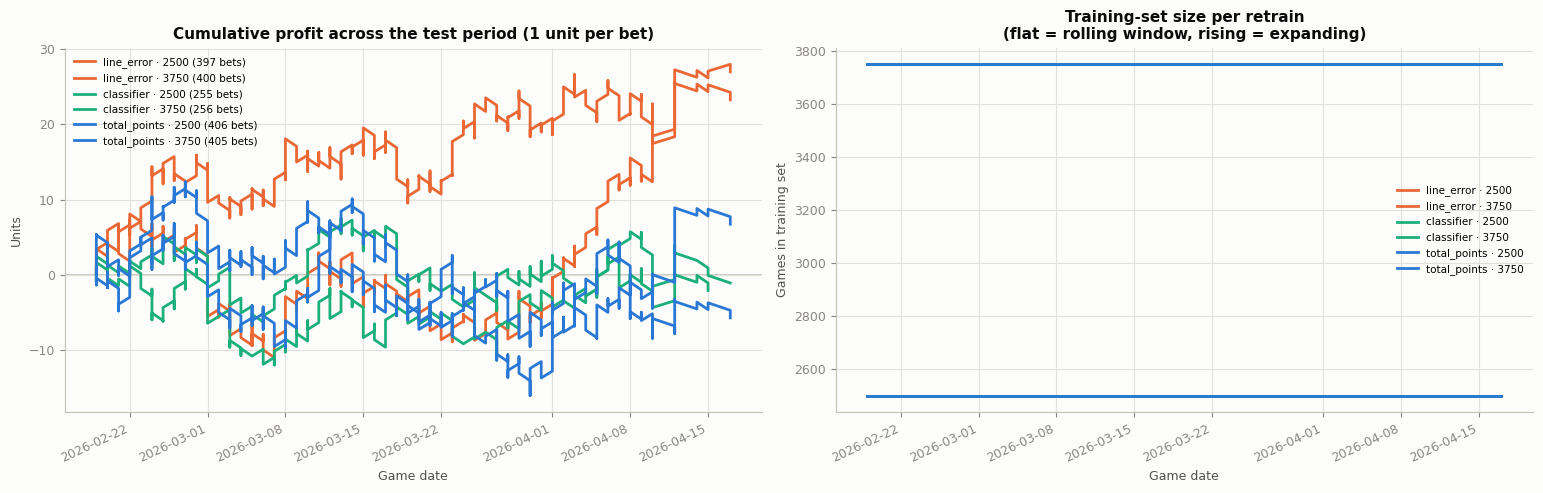

✅ **No run trained on data at or after its own prediction date.**

,label,game_days,leakage_days
0,line_error · 2500,55,0
1,line_error · 3750,55,0
2,classifier · 2500,55,0
3,classifier · 3750,55,0
4,total_points · 2500,55,0
5,total_points · 3750,55,0


A curve that climbs once and then drifts sideways is one good week, not a strategy. Look for a slope that persists across the whole period.

In [30]:
audit = charts.plot_walk_forward(runs)
if audit is None:
    display(Markdown("_No daily walk-forward artifacts found._"))
else:
    show(narrative.leakage(audit))
    display(audit)
    display(Markdown(
        "A curve that climbs once and then drifts sideways is one good week, not a strategy. "
        "Look for a slope that persists across the whole period."
    ))

## 12. The closing line versus a line you could have bet

Everything above settles against the **closing** line — the market's final, sharpest price, and the
right bar for *"does this model know something?"*. But it is the last price quoted, so it is not one
you could have taken.

Beating the close proves information. Beating the opener *would* prove that information was
**capturable** — but only if the model could run at opener time. **If the closing line is itself one
of the model's features, that comparison is circular**, and the bet is unplaceable because at opener
time the closing line does not exist. The check below reads each run's `feature_schema.json` and says
so explicitly.

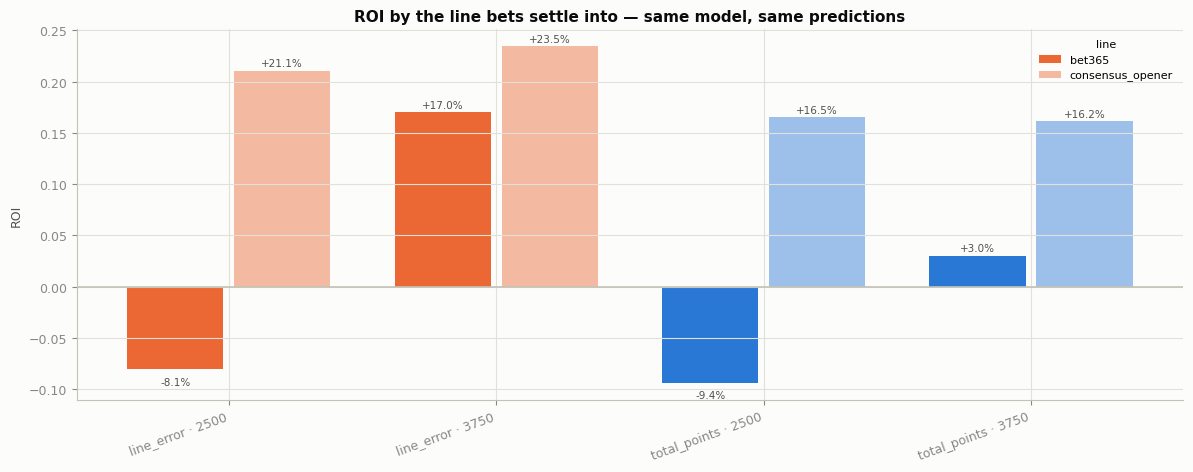

,label,measured_on,line_col,line_is_a_feature,line_mae,mean_abs_move_vs_first,n_bets,win_rate,roi,is_significant
0,line_error · 2500,CV folds,TOTAL_LINE_bet365,True,14.906,0.000,108,48.15%,-8.08%,False
1,line_error · 2500,CV folds,TOTAL_LINE_consensus_opener,True,15.469,3.066,392,63.57%,21.08%,True
2,line_error · 3750,CV folds,TOTAL_LINE_bet365,True,14.906,0.000,124,61.29%,17.01%,True
3,line_error · 3750,CV folds,TOTAL_LINE_consensus_opener,True,15.469,3.066,393,64.86%,23.46%,True
4,total_points · 2500,CV folds,TOTAL_LINE_bet365,True,14.906,0.000,273,47.43%,-9.42%,False
5,total_points · 2500,CV folds,TOTAL_LINE_consensus_opener,True,15.469,3.066,377,61.13%,16.52%,True
6,total_points · 3750,CV folds,TOTAL_LINE_bet365,True,14.906,0.000,316,53.97%,3.02%,False
7,total_points · 3750,CV folds,TOTAL_LINE_consensus_opener,True,15.469,3.066,425,60.95%,16.17%,True


- 🚨 **line_error · 2500**: -8.08% vs `TOTAL_LINE_bet365` → **+21.08%** vs `TOTAL_LINE_consensus_opener`. **Do not read this as an edge.** `TOTAL_LINE_bet365` is one of this model's input features, so the model was given the market's closing number and then scored against the earlier opener. The apparent gain is circular, and the bet is unplaceable: at the time the opener is quoted, the closing line does not exist yet. To measure this honestly, retrain with the closing line and every feature derived from it excluded.

- 🚨 **line_error · 3750**: +17.01% vs `TOTAL_LINE_bet365` → **+23.46%** vs `TOTAL_LINE_consensus_opener`. **Do not read this as an edge.** `TOTAL_LINE_bet365` is one of this model's input features, so the model was given the market's closing number and then scored against the earlier opener. The apparent gain is circular, and the bet is unplaceable: at the time the opener is quoted, the closing line does not exist yet. To measure this honestly, retrain with the closing line and every feature derived from it excluded.

- 🚨 **total_points · 2500**: -9.42% vs `TOTAL_LINE_bet365` → **+16.52%** vs `TOTAL_LINE_consensus_opener`. **Do not read this as an edge.** `TOTAL_LINE_bet365` is one of this model's input features, so the model was given the market's closing number and then scored against the earlier opener. The apparent gain is circular, and the bet is unplaceable: at the time the opener is quoted, the closing line does not exist yet. To measure this honestly, retrain with the closing line and every feature derived from it excluded.

- 🚨 **total_points · 3750**: +3.02% vs `TOTAL_LINE_bet365` → **+16.17%** vs `TOTAL_LINE_consensus_opener`. **Do not read this as an edge.** `TOTAL_LINE_bet365` is one of this model's input features, so the model was given the market's closing number and then scored against the earlier opener. The apparent gain is circular, and the bet is unplaceable: at the time the opener is quoted, the closing line does not exist yet. To measure this honestly, retrain with the closing line and every feature derived from it excluded.

In [31]:
lines = charts.plot_line_comparison(runs)
if lines is None:
    display(Markdown(
        "_No alternative-line scoring. Add_ "
        "`betting: {comparison_line_cols: [\"TOTAL_LINE_consensus_opener\"]}` _and rerun._"
    ))
else:
    display(theme.percent_frame(
        lines[["label", "measured_on", "line_col", "line_is_a_feature", "line_mae",
               "mean_abs_move_vs_first", "n_bets", "win_rate", "roi", "is_significant"]],
        percent=["win_rate", "roi"],
        decimals=["line_mae", "mean_abs_move_vs_first"],
    ))
    show(narrative.line_comparison(lines))

## 13. What actually differs between these runs

Only fields that vary, split into those that change results and those that are just labels. With many
runs in one view this is the fastest way to see whether an apparent strategy effect is confounded by
something else changing at the same time.

In [32]:
LABEL_KEYS = {
    "experiment_name", "training_version", "comparison_group", "hypothesis", "tags",
    "data.data_version", "data.expected_checksum", "window_dir_label", "window_name_label",
    "experiment_root_dir", "model_output_root", "save_experiment_artifacts",
}

configs = {row["label"]: loaders.load_config_flat(row) for _, row in runs.iterrows()}
configs = {k: v for k, v in configs.items() if v}

if not configs:
    display(Markdown("_No `config.json` found._"))
else:
    matrix = pd.DataFrame(configs).sort_index()
    differs = matrix.apply(lambda r: r.astype(str).nunique(dropna=False) > 1, axis=1)
    differences = matrix.loc[differs]
    substantive = differences.loc[~differences.index.isin(LABEL_KEYS)]
    labels_only = differences.loc[differences.index.isin(LABEL_KEYS)]

    display(Markdown("**Differences that affect results**"))
    display(substantive if not substantive.empty
            else Markdown("_None — every run here is configured identically._"))
    if not labels_only.empty:
        display(Markdown("**Descriptive only (no effect on results)**"))
        display(labels_only)
    show(narrative.config_differences(substantive, len(configs)))

**Differences that affect results**

,line_error · 2500,line_error · 3750,classifier · 2500,classifier · 3750,total_points · 2500,total_points · 3750
line_col,None,None,TOTAL_LINE_bet365,TOTAL_LINE_bet365,TOTAL_LINE_bet365,TOTAL_LINE_bet365
optuna.objective_name,reg:squarederror,reg:squarederror,binary:logistic,binary:logistic,reg:squarederror,reg:squarederror
optuna.search_space.gamma.high,500.0,500.0,2.0,2.0,500.0,500.0
optuna.search_space.gamma.low,1.0,1.0,0.002,0.002,1.0,1.0
optuna.search_space.min_child_weight.high,250.0,250.0,60.0,60.0,250.0,250.0
optuna.search_space.min_child_weight.low,20.0,20.0,5.0,5.0,20.0,20.0
optuna.search_space.reg_alpha.high,20.0,20.0,2.0,2.0,20.0,20.0
optuna.search_space.reg_alpha.low,0.01,0.01,0.001,0.001,0.01,0.01
optuna.search_space.reg_lambda.high,500.0,500.0,150.0,150.0,500.0,500.0
optuna.search_space.reg_lambda.low,1.0,1.0,0.5,0.5,1.0,1.0


**Descriptive only (no effect on results)**

,line_error · 2500,line_error · 3750,classifier · 2500,classifier · 3750,total_points · 2500,total_points · 3750
experiment_name,line_error_2500,line_error_3750,classifier_2500,classifier_3750,total_points_2500,total_points_3750
hypothesis,"Predicting total-minus-line subtracts out the nuisance part, so the whole target is the quantity...","Predicting total-minus-line subtracts out the nuisance part, so the whole target is the quantity...","Predicting P(OVER) takes the same logic to its limit, at the cost of discarding magnitude -- a g...","Predicting P(OVER) takes the same logic to its limit, at the cost of discarding magnitude -- a g...","Predicting the total spends most of the loss reproducing the line, which the model can already r...","Predicting the total spends most of the loss reproducing the line, which the model can already r..."
tags,"[""line_error"", ""2500_games"", ""strategy_window_campaign""]","[""line_error"", ""3750_games"", ""strategy_window_campaign""]","[""classifier"", ""2500_games"", ""strategy_window_campaign""]","[""classifier"", ""3750_games"", ""strategy_window_campaign""]","[""total_points"", ""2500_games"", ""strategy_window_campaign""]","[""total_points"", ""3750_games"", ""strategy_window_campaign""]"


_13 substantive field(s) differ across 6 run(s). Where more than one differs between any two runs, their difference in outcome cannot be attributed to a single cause._

## Reading this — a checklist

Roughly in the order each question invalidates the ones after it:

1. **Is the gap bigger than the seed noise?** (§3) If two runs differ by less than one run's own
   spread across seeds, there is nothing to explain. This dismisses more apparent findings than
   anything else here.
2. **Is the sample balanced?** (§1) Conclusions about a strategy that got one run are about that run.
3. **Same holdout cohort, comparable selectivity?** (§2) The threshold is points for regressors and
   expected value for the classifier.
4. **Is there enough volume to prove anything?** (§4) An interval crossing 52.38% means "not proven".
5. **Do CV and holdout agree?** (§5) A large gap in *either* direction is a warning.
6. **Is the edge spread across folds or carried by two?** (§10)
7. **Does confidence predict winning?** (§9) If not, the minimum-edge filter costs volume and returns
   nothing.
8. **For classifiers: are the probabilities honest?** (§8) A miscalibrated probability makes the
   expected-value filter systematically wrong even when the ranking is good.
9. **Would the edge survive at a bettable price — and is that comparison even legitimate?** (§12)
10. **Is the profit steady or one good week?** (§11)
11. **Is anything else confounded?** (§13)

Record conclusions in each experiment's `hypothesis` field or a campaign README — not in the plots,
which get regenerated.